In [1]:
import pandas as pd

train = pd.read_csv("../data/store_sales/train.csv")

train.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [2]:
print("Shape:", train.shape)
print("\nColumns:")
print(train.columns.tolist())
print("\nMissing values:")
print(train.isnull().sum())
print("\nData types:")
print(train.dtypes)

Shape: (3000888, 6)

Columns:
['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion']

Missing values:
id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

Data types:
id               int64
date               str
store_nbr        int64
family             str
sales          float64
onpromotion      int64
dtype: object


In [3]:
train["date"] = pd.to_datetime(train["date"])

print(train.dtypes)

id                      int64
date           datetime64[us]
store_nbr               int64
family                    str
sales                 float64
onpromotion             int64
dtype: object


In [4]:
print("Stores:", train["store_nbr"].nunique())
print("Product categories:", train["family"].nunique())
print("Date range:", train["date"].min(), "to", train["date"].max())

Stores: 54
Product categories: 33
Date range: 2013-01-01 00:00:00 to 2017-08-15 00:00:00


<Axes: title={'center': 'Daily Total Sales'}, xlabel='date'>

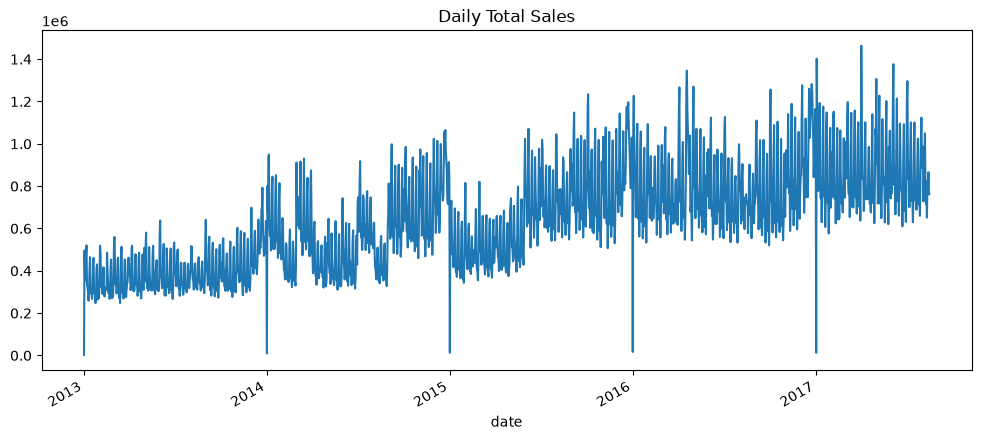

In [5]:
daily_sales = train.groupby("date")["sales"].sum()

daily_sales.plot(figsize=(12, 5), title="Daily Total Sales")

<Axes: title={'center': 'Monthly Total Sales'}, xlabel='date'>

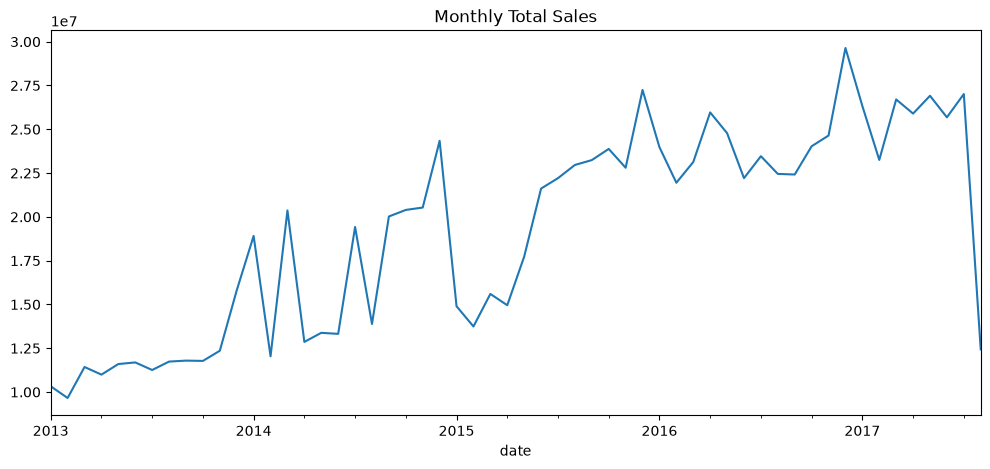

In [6]:
monthly_sales = train.groupby(
    train["date"].dt.to_period("M")
)["sales"].sum()

monthly_sales.plot(
    figsize=(12, 5),
    title="Monthly Total Sales"
)

In [7]:
category_sales = train.groupby("family")["sales"].sum().sort_values(ascending=False)

category_sales.head(10)

family
GROCERY I        3.434627e+08
BEVERAGES        2.169545e+08
PRODUCE          1.227047e+08
CLEANING         9.752129e+07
DAIRY            6.448771e+07
BREAD/BAKERY     4.213395e+07
POULTRY          3.187600e+07
MEATS            3.108647e+07
PERSONAL CARE    2.459205e+07
DELI             2.411032e+07
Name: sales, dtype: float64

<Axes: title={'center': 'GROCERY I - Monthly Sales'}, xlabel='date'>

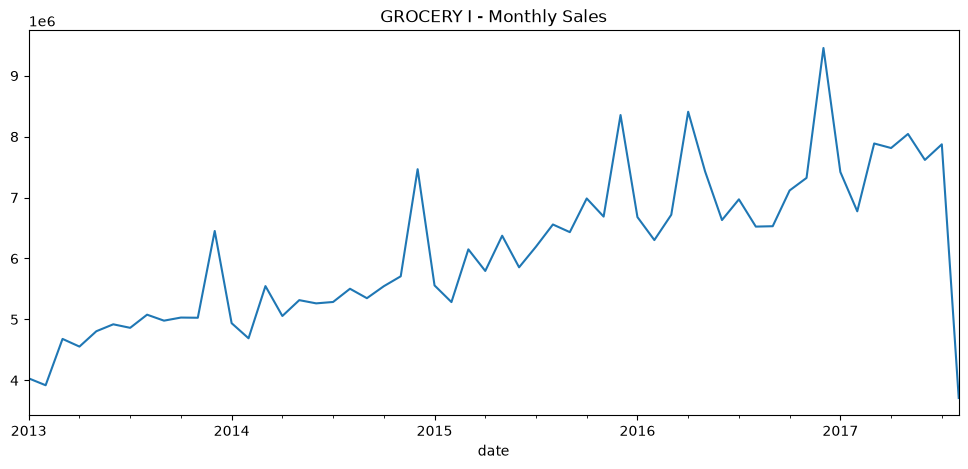

In [8]:
grocery = train[train["family"] == "GROCERY I"]

grocery_monthly = grocery.groupby(
    grocery["date"].dt.to_period("M")
)["sales"].sum()

grocery_monthly.plot(
    figsize=(12, 5),
    title="GROCERY I - Monthly Sales"
)

In [9]:
promo_sales = train.groupby("onpromotion")["sales"].mean()

promo_sales

onpromotion
0       158.246681
1       467.556532
2       662.925632
3       871.408092
4       969.916135
          ...     
719    6681.000000
720    6154.000000
722    5846.000000
726    6044.000000
741    7517.000000
Name: sales, Length: 362, dtype: float64